# Test of cobaya using 2 exercices in documentation

In [1]:
import getdist.plots as gdplt
import cobaya

In [2]:
from cobaya.yaml import yaml_load_file
from cobaya.run import run

# Load the YAML file
info = yaml_load_file("gaussian.yaml")
# updated_info, sampler = run(info, force=True) # run the sampler and get the updated info
# gd_sample = sampler.products(to_getdist=True, skip_samples=0.3)["sample"]

gd_sample = cobaya.load_samples(info["output"], to_getdist=True) # load samples to getdist from existing output

In [3]:
# analysis and plots
mean = gd_sample.getMeans()[:2]
covmat = gd_sample.getCovMat().matrix[:2, :2]
print("Mean:", mean)
print("Covariance matrix:\n", covmat)

Mean: [ 0.2048627  -0.02035086]
Covariance matrix:
 [[0.09077444 0.04083277]
 [0.04083277 0.16224286]]


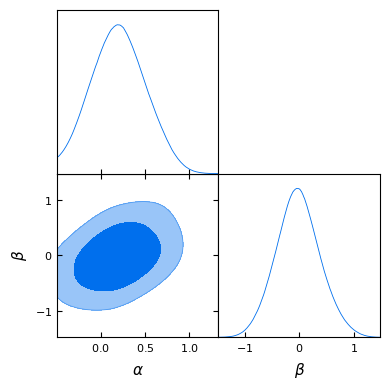

In [4]:
gdplot = gdplt.get_subplot_plotter()
gdplot.triangle_plot(gd_sample, ["a", "b"], filled=True)

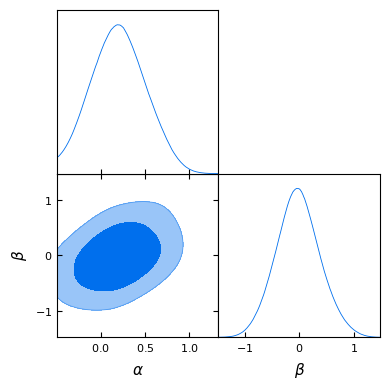

In [5]:
# Just plotting (loading on-the-fly)
# Notice that GetDist requires a full path when loading samples
import os

import getdist.plots as gdplt

folder, name = os.path.split(os.path.abspath(info["output"]))
gdplot = gdplt.get_subplot_plotter(chain_dir=folder)
gdplot.triangle_plot(name, ["a", "b"], filled=True)

# Ex2 python fct likeliood

In [6]:
import numpy as np
from scipy import stats


def gauss_ring_logp(x, y, mean_radius=1, std=0.01):
    """
    Defines a gaussian ring likelihood in cartesian coordinates,
    around some ``mean_radius`` and with some ``std``.
    """
    return stats.norm.logpdf(np.sqrt(x**2 + y**2), loc=mean_radius, scale=std)

def x_eq_y_band(x, y, mean=0, std=0.3):
    return stats.norm.logpdf(x - y, loc=mean, scale=std)

def get_r(x, y):
    return np.sqrt(x ** 2 + y ** 2)


def get_theta(x, y):
    return np.arctan(y / x)

In [7]:
info = {"likelihood": {"ring": gauss_ring_logp}}

info["params"] = {
    "x": {"prior": {"min": 0, "max": 2}, "ref": 1.5, "proposal": 0.1},
    "y": {"prior": {"min": 0, "max": 2}, "ref": 1.5, "proposal": 0.1}}

info["prior"] = {"x_eq_y_band": x_eq_y_band}

info["params"]["r"] = {"derived": get_r}
info["params"]["theta"] = {"derived": get_theta,
                           "latex": r"\theta", "min": 0, "max": np.pi/2}

info["sampler"] = {"mcmc": {"Rminus1_stop": 0.01, "max_tries": 1000}} # diagonalized Gelman-Rubin 

In [8]:
updated_info, sampler = run(info)

[prior] *WARNING* External prior 'x_eq_y_band' loaded. Mind that it might not be normalized!


INFO:ring:Initialized external likelihood.


[ring] Initialized external likelihood.


INFO:mcmc:Getting initial point... (this may take a few seconds)


[mcmc] Getting initial point... (this may take a few seconds)


...

[mcmc]  - Convergence of bounds: R-1 = 0.080095 after 3200 accepted steps


INFO:mcmc:The run has converged!


[mcmc] The run has converged!


INFO:mcmc:Sampling complete after 3200 accepted steps.


[mcmc] Sampling complete after 3200 accepted steps.


In [9]:
gd_sample = sampler.products(to_getdist=True, skip_samples=0.3)["sample"]

[root] *WARNING* outlier fraction 0.010267857142857143 


Mean: [0.68171028 0.6947681 ]
Covariance matrix:
 [[ 0.027165   -0.02494861]
 [-0.02494861  0.02550597]]


(2, 1)

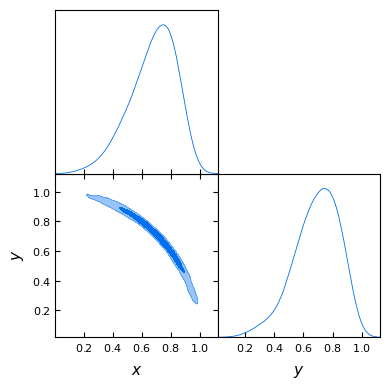

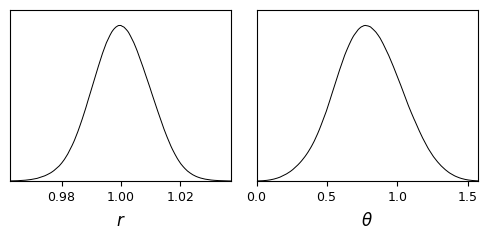

In [10]:
# analysis and plots
mean = gd_sample.getMeans()[:2]
covmat = gd_sample.getCovMat().matrix[:2, :2]
print("Mean:", mean)
print("Covariance matrix:\n", covmat)
gdplot = gdplt.get_subplot_plotter()
gdplot.triangle_plot(gd_sample, ["x", "y"], filled=True)

gdplot = gdplt.get_subplot_plotter(width_inch=5)
gdplot.plots_1d(gd_sample, ["r", "theta"], nx=2)